# Exploratory Data Analysis (EDA): preliminar raw Smart Card and AVL data from Santiago, Chile.

Last reviewed: Saturday 09-05-2026

Times this file has been edited: 11

Hardware specs:

1. *Portable* branch:
    * Machine: MacBook Air (13-inch, 2017)
    * OS: MacOS Monterey v12.7.6
    * CPU: 1.8 GHz Intel Core i5 de dos núcleos
    * RAM: 8 GB 1600 MHz DDR3
    * Graphics: Intel HD Graphics 6000 1536 MB

2. *House* branch:
    * OS: Windows 10 Home 64-bit (10.0, Build 19045)
    * Processor: Intel(R) Core(TM) i7-8700K CPU @ 3.70GHz (12 CPUs), ~3.7GHz
    * Memory: 12288MB RAM
    * GPU: NVIDIA GeForce RTX 3060 12115 MB


## Trips (smart card data)

Available data:
* 2014
    * 2014-05-26 to 2014-05-30 (Mon-Fri)
* 2015
    * 2015-04-20 to 2015-04-24 (Mon-Fri)
* 2016
    * 2016-05-23 to 2016-05-27 (Mon-Fri)
* 2017
    * 2017-04-03 to 2017-04-07 (Mon-Fri, except Wed)
    * 2017-04-12 (Wed)
* 2018
    * 2018-04-09 to 2018-04-13 (Mon-Fri)
    * 2018-05-01 to 2018-05-07 (Tue-Mon)*
    * 2018-05-14 to 2018-05-20 (Mon-Sun)*
    * 2018-10-08 to 2018-10-12 (Mon-Fri)
* 2019
    * 2019-04-08 to 2019-04-14 (Mon-Sun)
    * 2019-05-13 to 2019-05-19 (Mon-Sun)*
    * 2019-08-05 to 2019-08-12 (Mon-Sun)
* 2020
    * 2020-03-07 to 2020-03-13 (Mon-Sun)
    * 2020-11-09 to 2020-11-15 (Mon-Sun)
* 2021
    * 2021-04-12 to 2021-04-18 (Mon-Sun)
    * 2021-11-08 to 2021-11-14 (Mon-Sun)
* 2022
    * 2022-04-04 to 2022-04-10 (Mon-Sun)
    * 2022-08-08 to 2022-08-14 (Mon-Sun)
* 2023
    * 2023-04-17 to 2023-04-23 (Mon-Sun)
    * 2023-08-07 to 2023-08-13 (Mon-Sun)
    * 2023-11-01 to 2023-11-07 (Wed-Tue)*
    * 2023-11-08 to 2023-11-12 (Wed-Sun)
* 2024
    * 2024-04-15 to 2024-04-21 (Mon-Sun)
    * 2024-11-01 to 2024-11-29 (Fri-Fri)*
* 2025
    * 2025-04-21 to 2025-04-27 (Mon-Sun)

*Data made available by Eduardo.

### Sample 1: 2019-05-19 (Sunday)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from sklearn.model_selection import train_test_split

In [ ]:
# Opciones modificables
pd.set_option('display.max_columns', None)

In [ ]:
trips_df = pd.read_csv('../data/raw/Trips/2019-05-19.viajes', sep='|', low_memory=False)

In [ ]:
trips_df.head()

#### Column analysis & missing data

In [ ]:
print("=== DIMENSIONES ===")
print(f"Filas: {trips_df.shape[0]:,}   Columnas: {trips_df.shape[1]}")

print("\n=== TIPOS DE DATOS ===")
print(trips_df.dtypes.value_counts())

In [ ]:
trips_df = trips_df.replace('-', np.nan)

In [ ]:
print("=== NULOS POR COLUMNA (%) ===")
nulos = (trips_df.isnull().sum() / len(trips_df) * 100).sort_values(ascending=False)
print(nulos[nulos > 0].round(2).to_string())

In [ ]:
# Conteo de columnas según umbrales de porcentaje de nulos
umbrales = [99, 95, 90, 50]

print("Cantidad de columnas con porcentaje de nulos mayor a cada umbral:")
for u in umbrales:
    cantidad = (nulos > u).sum()
    print(f"Mayor a {u}%: {cantidad}")

In [ ]:
trips_df.describe().T.round(2)

In [ ]:
print("=== Columnas con 100% de nulos ===")
print(nulos[nulos == 100].to_string())
print(f"Total: {(nulos == 100).sum()} columnas")

Observaciones: 
* De las 109 columnas del dataset, casi 1/3 de ellas tienen un porcentaje de nulos mayor al 99%.
* En esta data no parece factible hacer un análisis etáreo entre escolares y no escolares, pues no hay data en la columna `escolar` que permita hacer esa discriminación.
* No hay data de la distancia de viaje en bus pero es estimable.
* Otra info que podría ser de interés pero no se encuentra presente corresponde a las etapas del viaje.

In [ ]:
# Mostrar todas las columnas del dataset de forma legible
print("Variables del dataset trips_df:")
print("=" * 50)

for i, col in enumerate(trips_df.columns, 1):
    print(f"{i:3d}. {col}")

print(f"\nTotal de variables: {len(trips_df.columns)}")

In [ ]:
trips_df['tipo_corte_etapa_viaje'].value_counts(dropna=False)

#### ID analysis

In [ ]:
# Contar la frecuencia de cada ID
id_counts = trips_df['id'].value_counts()

# Contar cuántos IDs aparecen cada cantidad de veces
frequency_distribution = id_counts.value_counts().sort_index()

print("Distribución de frecuencias de IDs:")
print("=" * 40)
for freq, count in frequency_distribution.items():
    print(f"IDs que aparecen {freq} vez(es): {count}")

print(f"\nTotal de IDs únicos: {len(id_counts)}")
print(f"Máximo número de apariciones de un ID: {id_counts.max()}")
print(f"Mínimo número de apariciones de un ID: {id_counts.min()}")

In [ ]:
# Gráfico de barras de distribución de frecuencias de IDs
# agrupando en una sola barra las categorías que representan < 0.5% de IDs únicos

umbral_pct = 0.5

total_ids_unicos = id_counts.shape[0]
freq_dist = frequency_distribution.copy()
freq_pct = (freq_dist / total_ids_unicos) * 100

# Mantener categorías >= 0.5%
freq_principales = freq_dist[freq_pct >= umbral_pct].copy()

# Agrupar categorías < 0.5%
freq_agrupadas = freq_dist[freq_pct < umbral_pct].sum()

# Serie final para graficar
plot_data = freq_principales.copy()
if freq_agrupadas > 0:
    plot_data.loc[f'Otros (<{umbral_pct}% c/u)'] = freq_agrupadas

# Etiquetas para el eje X
x_labels = [str(x) for x in plot_data.index]

plt.figure(figsize=(12, 6))
plt.bar(x_labels, plot_data.values, color='steelblue', edgecolor='black')
plt.title('Distribución de Frecuencias de IDs (agrupación < 0.5%)')
plt.xlabel('Frecuencia de aparición del ID')
plt.ylabel('Cantidad de IDs')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total de IDs únicos: {total_ids_unicos}")
print(f"Categorías agrupadas (<{umbral_pct}%): {(freq_pct < umbral_pct).sum()}")

###### IDs with 1 appearance

In [ ]:
# Mostrar las instancias de los primeros 10 IDs que aparecen solo una vez
ids_unicos_una_vez = id_counts[id_counts == 1].head(10).index

instancias_ids_una_vez = trips_df[trips_df['id'].isin(ids_unicos_una_vez)].copy()

print("Primeros 10 IDs que aparecen solo una vez:")
print(ids_unicos_una_vez.tolist())
print(f"\nCantidad de filas encontradas: {len(instancias_ids_una_vez)}")

instancias_ids_una_vez

In [ ]:
# Porcentaje de nulos en 'paraderobajada' para IDs que aparecen una sola vez

ids_una_vez = id_counts[id_counts == 1].index
df_ids_una_vez = trips_df[trips_df['id'].isin(ids_una_vez)]

pct_nulos_paraderobajada = df_ids_una_vez['paraderobajada'].isna().mean() * 100

print(f"Porcentaje de nulos en 'paraderobajada' (IDs con una sola aparición): {pct_nulos_paraderobajada:.2f}%")
print(f"Total de registros considerados: {len(df_ids_una_vez):,}")

###### IDs with 2 appearances

In [ ]:
# Mostrar las instancias de los primeros 5 IDs que aparecen exactamente dos veces
ids_dos_veces = id_counts[id_counts == 2].head(5).index
instancias_ids_dos_veces = trips_df[trips_df['id'].isin(ids_dos_veces)].copy()

print("Primeros 5 IDs que aparecen dos veces:")
print(ids_dos_veces.tolist())
print(f"\nCantidad de filas encontradas: {len(instancias_ids_dos_veces)}")

instancias_ids_dos_veces

In [ ]:
trips_df['netapa'].value_counts(dropna=False)

In [ ]:
trips_df[trips_df['netapa'] == 6]

**Observación:** La columna netapa aparenta ser la cantidad de etapas que tuvo el viaje, lo que debería por definición corresponder a la columna etapas.

In [ ]:
ids_dos_veces = id_counts[id_counts == 2].index
df_ids_dos_veces = trips_df[trips_df['id'].isin(ids_dos_veces)]

pct_nulos_paraderobajada = df_ids_dos_veces['paraderobajada'].isna().mean() * 100

print(f"Porcentaje de nulos en 'paraderobajada' (IDs con dos apariciones): {pct_nulos_paraderobajada:.2f}%")
print(f"Total de registros considerados: {len(df_ids_dos_veces):,}")

###### Analysis of extreme ID with high number of appearances

In [ ]:
id_counts.head()

In [ ]:
# Caso de 28 apariciones
appears_28 = id_counts[id_counts == 28].index
trips_df[trips_df['id'] == appears_28[0]]

In [ ]:
# Caso de 26 apariciones
appears_26 = id_counts[id_counts == 26].index
trips_df[trips_df['id'] == appears_26[0]]

##### **Conclusiones generales:**
* Más de un 86% de los usuarios registrados en el dataset realizaron uno o dos viajes el día estudiado.
* Se puede observar que situaciones extremas como el ID con 28 viajes muestra instancias repetidas que sugieren errores/imprecisiones en el dataset. 

#### Trip legs analysis

In [ ]:
trips_df['netapa'].value_counts(dropna=False)

In [ ]:
trips_df[trips_df['netapa'] == 6]

In [ ]:
trips_df['ultimaetapaconbajada'].value_counts()

In [ ]:
trips_df[(trips_df['ultimaetapaconbajada'] == 1) & trips_df['tviaje_seg'].notna()].shape

In [ ]:
trips_df['paraderosubida'].nunique()

In [ ]:
trips_df['paraderobajada'].nunique()

In [ ]:
pares_validos = trips_df[['paraderosubida', 'paraderobajada']].dropna()
cantidad_pares_diferentes = pares_validos.drop_duplicates().shape[0]

print(f"Cantidad de pares diferentes (sin nulos): {cantidad_pares_diferentes:,}")

In [ ]:
top10_pares = (
	pares_validos
	.value_counts()
	.rename("frecuencia")
	.reset_index()
	.head(10)
)

print("Top 10 pares (paraderosubida, paraderobajada) más frecuentes:")
print(top10_pares.to_string(index=False))

In [ ]:
trips_df[(trips_df['paraderosubida'] == 'TOBALABA L1') & (trips_df['paraderobajada'] == 'TOBALABA')].head()

#### Travel time analysis

In [ ]:
trips_df['tviaje_seg'] = pd.to_numeric(trips_df['tviaje_seg'], errors='coerce')

In [ ]:
plt.figure(figsize=(12, 6))
plt.hist(trips_df['tviaje_seg'].dropna(), bins=50, alpha=0.7, edgecolor='black')
plt.title('Distribución de Tiempo de Viaje en Segundos')
plt.xlabel('Tiempo de Viaje (segundos)')
plt.ylabel('Frecuencia')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
trips_df['tviaje_seg'].describe().round(2)

#### Purpose of trip analysis

In [ ]:
# Estadísticas de la columna 'proposito'
print("Estadísticas de la columna 'proposito':")
print("=" * 50)

# Conteo de valores únicos
proposito_counts = trips_df['proposito'].value_counts()
print("\nDistribución de propósitos:")
print(proposito_counts)

# Porcentajes
proposito_percentages = trips_df['proposito'].value_counts(normalize=True) * 100
print("\nDistribución de propósitos (porcentajes):")
print(proposito_percentages.round(2))

# Información adicional
print(f"\nNúmero de valores únicos: {trips_df['proposito'].nunique()}")
print(f"Valores nulos: {trips_df['proposito'].isnull().sum()}")
print(f"Total de registros: {len(trips_df)}")

# Mostrar los valores únicos
print(f"\nValores únicos en 'proposito': {trips_df['proposito'].unique()}")

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(proposito_counts.index, proposito_counts.values)
plt.title('Distribución de Propósitos de Viaje')
plt.xlabel('Propósito')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

#### Geographical analysis

In [ ]:
trips_df['comunasubida'].value_counts(dropna=False)

In [ ]:
trips_df['comunabajada'].value_counts(dropna=False)

##### Correlación de dato faltante en comuna de bajada según comuna de subida

In [ ]:
# Indicador de dato faltante en comunabajada (1 = faltante, 0 = no faltante)
missing_comunabajada = trips_df['comunabajada'].isna().astype(int)

# Matriz (porcentaje por comuna de subida)
matriz_faltantes = (
    pd.crosstab(
        trips_df['comunasubida'].fillna('SIN_COMUNA_SUBIDA'),
        missing_comunabajada,
        normalize='index'
    ) * 100
).rename(columns={0: 'comunabajada_no_faltante_%', 1: 'comunabajada_faltante_%'})

print("Matriz de porcentajes de faltantes en 'comunabajada' por 'comunasubida':")
display(matriz_faltantes.sort_values('comunabajada_faltante_%', ascending=False))

# Correlación (tipo point-biserial) entre cada comuna de subida (one-hot) y faltante en comunabajada
comunasubida_dummies = pd.get_dummies(
    trips_df['comunasubida'].fillna('SIN_COMUNA_SUBIDA'),
    prefix='comunasubida'
)

corr_missing = (
    comunasubida_dummies.corrwith(missing_comunabajada)
    .sort_values(ascending=False)
    .to_frame('corr_con_faltante_comunabajada')
)

print("Correlación de cada comuna de subida con faltantes en 'comunabajada':")
display(corr_missing)

# Heatmap de las 30 comunas con mayor porcentaje de faltantes
top30 = matriz_faltantes[['comunabajada_faltante_%']].sort_values(
    'comunabajada_faltante_%', ascending=False
).head(30)

plt.figure(figsize=(8, 10))
sns.heatmap(top30, annot=True, fmt=".2f", cmap='Reds', cbar_kws={'label': '% faltante'})
plt.title("Top 30 comunasubida con mayor % faltante en comunabajada")
plt.xlabel("")
plt.ylabel("comunasubida")
plt.tight_layout()
plt.show()

#### Time/space analysis

In [ ]:
# Identifica columnas candidatas a fechas
cols_tiempo = [c for c in trips_df.columns if "tiempo" in c.lower() or "subida" in c.lower()]
print("COLUMNAS TEMPORALES DETECTADAS")
for col in cols_tiempo[:6]:  # primeras 6
    print(f"   {col}: dtype={trips_df[col].dtype}  | muestra: {trips_df[col].dropna().iloc[0]}")

In [ ]:
print("DISTRIBUCIÓN horario subida por media hora (mediahora)")
print(trips_df['mediahora'].value_counts().to_string())

### Sample 2: 2024-11-15 (Friday)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from sklearn.model_selection import train_test_split

In [ ]:
trips2_df = pd.read_csv('../data/raw/Trips/2024-11-15.viajes.csv', sep='|', low_memory=False)

In [ ]:
trips2_df.head()

#### Column analysis & missing data

In [ ]:
print("=== DIMENSIONES ===")
print(f"Filas: {trips2_df.shape[0]:,}   Columnas: {trips2_df.shape[1]}")

print("\n=== TIPOS DE DATOS ===")
print(trips2_df.dtypes.value_counts())

In [ ]:
trips2_df = trips2_df.replace('-', np.nan)

In [ ]:
print("=== NULOS POR COLUMNA (%) ===")
nulos = (trips2_df.isnull().sum() / len(trips2_df) * 100).sort_values(ascending=False)
print(nulos[nulos > 0].round(2).to_string())

In [ ]:
print("=== Columnas con 0% de nulos ===")
print(nulos[nulos == 0].to_string())

In [ ]:
trips2_df.describe().T.round(2)

In [ ]:
print("=== Columnas con 100% de nulos ===")
print(nulos[nulos == 100].to_string())

In [ ]:
# Mostrar todas las columnas del dataset de forma legible
print("Variables del dataset trips2_df:")
print("=" * 50)

for i, col in enumerate(trips2_df.columns, 1):
    print(f"{i:3d}. {col}")

print(f"\nTotal de variables: {len(trips2_df.columns)}")

#### ID analysis

In [ ]:
# Contar la frecuencia de cada ID
id_counts = trips2_df['id_tarjeta'].value_counts()

# Contar cuántos IDs aparecen cada cantidad de veces
frequency_distribution = id_counts.value_counts().sort_index()

print("Distribución de frecuencias de IDs:")
print("=" * 40)
for freq, count in frequency_distribution.items():
    print(f"IDs que aparecen {freq} vez(es): {count}")

print(f"\nTotal de IDs únicos: {len(id_counts)}")
print(f"Máximo número de apariciones de un ID: {id_counts.max()}")
print(f"Mínimo número de apariciones de un ID: {id_counts.min()}")

In [ ]:
# Gráfico de barras de distribución de frecuencias de IDs
# agrupando en una sola barra las categorías que representan < 0.5% de IDs únicos

umbral_pct = 0.5

total_ids_unicos = id_counts.shape[0]
freq_dist = frequency_distribution.copy()
freq_pct = (freq_dist / total_ids_unicos) * 100

# Mantener categorías >= 0.5%
freq_principales = freq_dist[freq_pct >= umbral_pct].copy()

# Agrupar categorías < 0.5%
freq_agrupadas = freq_dist[freq_pct < umbral_pct].sum()

# Serie final para graficar
plot_data = freq_principales.copy()
if freq_agrupadas > 0:
    plot_data.loc[f'Otros (<{umbral_pct}% c/u)'] = freq_agrupadas

# Etiquetas para el eje X
x_labels = [str(x) for x in plot_data.index]

plt.figure(figsize=(12, 6))
plt.bar(x_labels, plot_data.values, color='steelblue', edgecolor='black')
plt.title('Distribución de Frecuencias de IDs (agrupación < 0.5%)')
plt.xlabel('Frecuencia de aparición del ID')
plt.ylabel('Cantidad de IDs')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total de IDs únicos: {total_ids_unicos}")
print(f"Categorías agrupadas (<{umbral_pct}%): {(freq_pct < umbral_pct).sum()}")

In [ ]:
id_counts.head()

In [ ]:
trips2_df[trips2_df['id_tarjeta'] == 966029820]

**Conclusiones generales:**
* Más de un 86% de los usuarios registrados en el dataset realizaron uno o dos viajes el día estudiado.
* Se puede observar que situaciones extremas como el ID con 28 viajes muestra instancias repetidas que sugieren errores/imprecisiones en el dataset. 

#### Travel time analysis

In [ ]:
trips_df['tviaje_seg'] = pd.to_numeric(trips_df['tviaje_seg'], errors='coerce')

In [ ]:
plt.figure(figsize=(12, 6))
plt.hist(trips_df['tviaje_seg'].dropna(), bins=50, alpha=0.7, edgecolor='black')
plt.title('Distribución de Tiempo de Viaje en Segundos')
plt.xlabel('Tiempo de Viaje (segundos)')
plt.ylabel('Frecuencia')
plt.grid(True, alpha=0.3)
plt.show()

#### Purpose of trip analysis

In [ ]:
# Estadísticas de la columna 'proposito'
print("Estadísticas de la columna 'proposito':")
print("=" * 50)

# Conteo de valores únicos
proposito_counts = trips_df['proposito'].value_counts()
print("\nDistribución de propósitos:")
print(proposito_counts)

# Porcentajes
proposito_percentages = trips_df['proposito'].value_counts(normalize=True) * 100
print("\nDistribución de propósitos (porcentajes):")
print(proposito_percentages.round(2))

# Información adicional
print(f"\nNúmero de valores únicos: {trips_df['proposito'].nunique()}")
print(f"Valores nulos: {trips_df['proposito'].isnull().sum()}")
print(f"Total de registros: {len(trips_df)}")

# Mostrar los valores únicos
print(f"\nValores únicos en 'proposito': {trips_df['proposito'].unique()}")

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(proposito_counts.index, proposito_counts.values)
plt.title('Distribución de Propósitos de Viaje')
plt.xlabel('Propósito')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

##### Time-distance analysis

## GPS

Available data:
* 2018-05-01 to 2018-05-07 (Tue-Mon)*
* 2022-12-01 to 2022-12-14 (Thu-Wed)*

### Sample 1: 2022-12-10 (Saturday)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from sklearn.model_selection import train_test_split

In [ ]:
gps_df = pd.read_csv('../data/raw/GPS/2022-12-10.gps', sep=';', header=None)

In [ ]:
gps_df.head()

#### Column analysis & missing data

In [ ]:
gps_df.info()

In [ ]:
# Convertir la columna 2 a formato datetime
try:
    gps_df[2] = pd.to_datetime(gps_df[2])
    print("Conversión exitosa a formato datetime")
    print(f"Tipo de dato de la columna 2: {gps_df[2].dtype}")
    print(f"Ejemplo de valores:\n{gps_df[2].head()}")
except:
    print("No se pudo convertir a datetime, separando en fecha y hora...")
    # Separar en fecha y hora
    gps_df['fecha'] = gps_df[2].str.split().str[0]
    gps_df['hora'] = gps_df[2].str.split().str[1]
    print("Columnas separadas:")
    print(f"Fecha: {gps_df['fecha'].head()}")
    print(f"Hora: {gps_df['hora'].head()}")

In [ ]:
print("=== NULOS POR COLUMNA (%) ===")
nulos = (gps_df.isnull().sum() / len(gps_df) * 100).sort_values(ascending=False)
print(nulos[nulos >= 0].round(2).to_string())

In [ ]:
# Contar la cantidad de instancias únicas por columna
print("=== CANTIDAD DE VALORES ÚNICOS POR COLUMNA ===")
unique_counts = gps_df.nunique()
print(unique_counts.to_string())

Las columnas 5, 6, 7 y 8 contienen un único valor y por ende son irrelevantes para realizar análisis.

##### First column

In [ ]:
# Contar la frecuencia de cada valor en la primera columna
columna_0_counts = gps_df[0].value_counts()

# Mostrar las 5 instancias que más veces aparecen
print("Top 5 valores más frecuentes en la columna 0:")
print("=" * 50)
print(columna_0_counts.head(5))

# Visualizar también as porcentajes
print("\nCon porcentajes:")
print((columna_0_counts.head(5) / len(gps_df) * 100).round(2))

# Mostrar las 5 instancias que menos veces aparecen
print("Top 5 valores menos frecuentes en la columna 0:")
print("=" * 50)
print(columna_0_counts.tail(5))

# Visualizar también as porcentajes
print("\nCon porcentajes:")
print((columna_0_counts.tail(5) / len(gps_df) * 100).round(2))

Primera columna muestra patentes, habiendo un 0.14% de los datos cuya patente en realidad es desconocida.

##### Second column

In [ ]:
# Contar la frecuencia de cada valor en la segunda columna
columna_1_counts = gps_df[1].value_counts(dropna=False)

# Mostrar las 10 instancias que más veces aparecen
print("Top 10 valores más frecuentes en la columna 1:")
print("=" * 50)
print(columna_1_counts.head(10))

# Visualizar también los porcentajes
print("\nCon porcentajes:")
print((columna_1_counts.head(10) / len(gps_df) * 100).round(2))

# Mostrar las 10 instancias que menos veces aparecen
print("Top 10 valores más frecuentes en la columna 1:")
print("=" * 50)
print(columna_1_counts.tail(10))

# Visualizar también los porcentajes
print("\nCon porcentajes:")
print((columna_1_counts.tail(10) / len(gps_df) * 100).round(2))

In [ ]:
# Histograma de la distribución de frecuencias en columna_1_counts
plt.figure(figsize=(10, 6))
plt.hist(columna_1_counts.values, bins=50, edgecolor='black', alpha=0.75, log=True)

plt.title("Histograma de los value counts de columna_1_counts")
plt.xlabel("Frecuencia (cantidad de apariciones por valor)")
plt.ylabel("Número de valores")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

La segunda columna aparenta ser una codificación de los recorridos, pero tiene notación un poco confusa.

##### Conclusiones

* Las primeras 5 columnas corresponden respectivamente a:
    1. Patente
    2. Recorrido
    3. Timestamp
    4. Latitud
    5. Longitud
* Se debe investigar más acerca de la columna de recorrido para poder mejorar la interpretabilidad a futuro.

#### Heatmaps of bus movement

In [ ]:
from plotly.subplots import make_subplots

import plotly.graph_objects as go
import plotly.express as px

# Preparar los datos para el mapa de calor animado
# Extraer hora del timestamp
gps_df['hora'] = gps_df[2].dt.hour
gps_df['minuto'] = gps_df[2].dt.minute

# Crear intervalos de tiempo de 15 minutos para el análisis
gps_df['intervalo_tiempo'] = gps_df['hora'] + (gps_df['minuto'] // 15) * 0.25

# Renombrar las columnas para mayor claridad
gps_df_clean = gps_df.rename(columns={3: 'latitud', 4: 'longitud'})

# Eliminar valores nulos en coordenadas
gps_df_clean = gps_df_clean.dropna(subset=['latitud', 'longitud'])

# Crear bins para las coordenadas (grilla para el mapa de calor)
lat_bins = 100
lon_bins = 100

# Calcular los rangos
lat_min, lat_max = gps_df_clean['latitud'].min(), gps_df_clean['latitud'].max()
lon_min, lon_max = gps_df_clean['longitud'].min(), gps_df_clean['longitud'].max()

# Crear el mapa de calor animado usando plotly
fig = px.density_mapbox(
    gps_df_clean.sample(50000),  # Muestrear para mejorar rendimiento
    lat='latitud',
    lon='longitud',
    animation_frame='intervalo_tiempo',
    mapbox_style='open-street-map',
    zoom=10,
    center=dict(lat=gps_df_clean['latitud'].mean(), lon=gps_df_clean['longitud'].mean()),
    title='Flujo de Buses durante el Día - Mapa de Calor Animado',
    labels={'intervalo_tiempo': 'Hora del día'}
)

# Actualizar el layout
fig.update_layout(
    width=1000,
    height=700,
    title_x=0.5
)

# Mostrar el mapa
fig.show()

In [ ]:
# Crear labels más legibles para la hora
gps_df_clean['hora_label'] = gps_df_clean['hora'].astype(str).str.zfill(2) + ':' + (gps_df_clean['minuto'] // 15 * 15).astype(str).str.zfill(2)

# Crear el mapa de calor animado con labels de tiempo mejorados
fig = px.density_mapbox(
    gps_df_clean.sample(50000),  # Muestrear para mejorar rendimiento
    lat='latitud',
    lon='longitud',
    animation_frame='hora_label',
    mapbox_style='open-street-map',
    zoom=10,
    center=dict(lat=gps_df_clean['latitud'].mean(), lon=gps_df_clean['longitud'].mean()),
    title='Flujo de Buses durante el Día - Mapa de Calor Animado',
    labels={'hora_label': 'Hora del día'}
)

# Actualizar el layout
fig.update_layout(
    width=1000,
    height=700,
    title_x=0.5
)

# Mostrar el mapa
fig.show()

In [ ]:
# Crear bins más finos para las coordenadas (grilla más detallada)
lat_bins = 150
lon_bins = 150

# Crear intervalos de tiempo más específicos (cada 15 minutos)
gps_df_clean['hora_completa'] = gps_df_clean['hora'] + (gps_df_clean['minuto'] // 15) * 0.25

# Crear labels ordenados cronológicamente
intervalos_ordenados = sorted(gps_df_clean['hora_completa'].unique())
gps_df_clean['hora_label_ordenada'] = gps_df_clean['hora_completa'].apply(
    lambda x: f"{int(x):02d}:{int((x % 1) * 60):02d}"
)

# Crear el mapa de calor animado con orden cronológico correcto
fig = px.density_mapbox(
    gps_df_clean.sample(75000),  # Muestra más grande para mejor resolución
    lat='latitud',
    lon='longitud',
    animation_frame='hora_label_ordenada',
    mapbox_style='open-street-map',
    zoom=11,
    center=dict(lat=gps_df_clean['latitud'].mean(), lon=gps_df_clean['longitud'].mean()),
    title='Flujo de Buses durante el Día (10-12-2022) - Mapa de Calor Animado',
    labels={'hora_label_ordenada': 'Hora del día'},
    category_orders={'hora_label_ordenada': sorted(gps_df_clean['hora_label_ordenada'].unique())}
)

# Actualizar el layout para mejor visualización
fig.update_layout(
    width=1200,
    height=800,
    title_x=0.5
)

# Mostrar el mapa
fig.show()

### Sample 2: 2018-05-01 (Tuesday, mandatory non-working holiday)

In [ ]:
gps2_df = pd.read_csv('../data/raw/GPS/2018-05-01.gps', sep=';', header=None)

In [ ]:
gps2_df.head()

#### Column analysis & missing data

In [ ]:
# Convertir la columna 2 a formato datetime
try:
    gps2_df[2] = pd.to_datetime(gps2_df[2])
    print("Conversión exitosa a formato datetime")
    print(f"Tipo de dato de la columna 2: {gps2_df[2].dtype}")
    print(f"Ejemplo de valores:\n{gps2_df[2].head()}")
except:
    print("No se pudo convertir a datetime, separando en fecha y hora...")
    # Separar en fecha y hora
    gps2_df['fecha'] = gps2_df[2].str.split().str[0]
    gps2_df['hora'] = gps2_df[2].str.split().str[1]
    print("Columnas separadas:")
    print(f"Fecha: {gps2_df['fecha'].head()}")
    print(f"Hora: {gps2_df['hora'].head()}")

In [ ]:
print("=== NULOS POR COLUMNA (%) ===")
nulos = (gps2_df.isnull().sum() / len(gps2_df) * 100).sort_values(ascending=False)
print(nulos[nulos >= 0].round(2).to_string())

In [ ]:
# Contar la cantidad de instancias únicas por columna
print("=== CANTIDAD DE VALORES ÚNICOS POR COLUMNA ===")
unique_counts = gps2_df.nunique()
print(unique_counts.to_string())

Aquí, las columnas 0 a 4 son las mismas que fueron descritas en la primera muestra, pero las columnas 5 a 9 parecen contener información relevante.

## Final Notes:
* Lots of valuable data between trips and GPS, but only intersects on one week from 2018-05-01 to 2018-05-07.
* Lots of OD choices. May allow for good consideration sets and research in levels of ocupation, transfers, and waiting/walking times.
* Solid trips dataset in terms of stages of trip, time and distance estimations, with low levels of missing data in relevant categories.
* Not a lot of sociodemographical data.
* Pre and post pandemic data available may allow research on systematic behavioural changes in route choice by users.

# EDA with preprocessed datasets

In [6]:
import duckdb
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

In [7]:
PROC = Path('D:/GitHub/tesis_magister_route_choice_modelling/data/parquets/01_raw')

archivos = {
    #"stages_2025": PROC / "Stages" / "2025" / "stages_2025_raw.parquet",
    "trips_2024":  PROC / "Trips"  / "2024" / "trips_2024_raw.parquet",
    #"trips_2025":  PROC / "Trips"  / "2025" / "trips_2025_raw.parquet",
}


In [ ]:
con = duckdb.connect()

for nombre, ruta in archivos.items():
    if not ruta.exists():
        print(f"[SKIP] {nombre} — archivo no encontrado")
        continue

    ruta_str = str(ruta).replace("\\", "/")
    print("=" * 60)
    print(f"DATASET: {nombre}")
    print("=" * 60)

    # Total de filas
    n = con.sql(f"SELECT COUNT(*) FROM read_parquet('{ruta_str}')").fetchone()[0]
    print(f"Filas totales: {n:,}")

    # Obtener nombres de columnas
    cols = con.sql(
        f"SELECT * FROM read_parquet('{ruta_str}') LIMIT 0"
    ).df().columns.tolist()

    print(f"Columnas totales: {len(cols)}")
    print()

    # Porcentaje de nulos o guiones por columna
    # Construimos la query completa como string para evitar f-strings anidadas
    select_parts = []
    for col in cols:
        parte = (
            f"COUNT(*) FILTER ("
            f"WHERE {col} IS NULL "
            f"OR TRIM(CAST({col} AS VARCHAR)) = '' "
            f"OR TRIM(CAST({col} AS VARCHAR)) = '-'"
            f") AS \"{col}\""
        )
        select_parts.append(parte)

    query = (
        f"SELECT {', '.join(select_parts)} "
        f"FROM read_parquet('{ruta_str}')"
    )

    resultado = con.sql(query).df()

    # Mostrar columnas con al menos 1% de nulos
    print(f"{'Columna':<40} {'Nulos/Guiones':>15} {'%':>8}")
    print("-" * 65)

    filas_con_nulos = {}
    for col in cols:
        cnt = resultado[col].iloc[0]
        pct = cnt / n * 100
        if pct >= 1.0:
            filas_con_nulos[col] = (cnt, pct)

    for col, (cnt, pct) in sorted(filas_con_nulos.items(), key=lambda x: -x[1][1]):
        barra = "█" * int(pct / 5)
        print(f"  {col:<38} {cnt:>12,}  {pct:>6.1f}%  {barra}")

    # Columnas completamente vacías
    vacias = [c for c in cols if resultado[c].iloc[0] == n]
    if vacias:
        print(f"\n  Columnas 100% vacías ({len(vacias)}):")
        for c in vacias:
            print(f"    - {c}")

    print()

con.close()
print("=" * 60)
print("Diagnóstico completado")
print("=" * 60)

DATASET: trips_2024
Filas totales: 24,430,419
Columnas totales: 102

Columna                                    Nulos/Guiones        %
-----------------------------------------------------------------
  tviaje                                   24,430,419   100.0%  ████████████████████
  column100                                24,430,419   100.0%  ████████████████████
  tc3                                      24,422,915   100.0%  ███████████████████
  te3                                      24,422,915   100.0%  ███████████████████
  tv4                                      24,422,204   100.0%  ███████████████████
  zona_bajada_4                            24,415,698    99.9%  ███████████████████
  paradero_bajada_4                        24,415,695    99.9%  ███████████████████
  tiempo_bajada_4                          24,415,637    99.9%  ███████████████████
  mediahora_bajada_4                       24,415,637    99.9%  ███████████████████
  periodo_bajada_4                       

In [ ]:
con = duckdb.connect()

for nombre, ruta in archivos.items():
    ruta_str = str(ruta).replace("\\", "/")

    n = con.sql(
        f"SELECT COUNT(*) FROM read_parquet('{ruta_str}')"
    ).fetchone()[0]

    cols = con.sql(
        f"SELECT * FROM read_parquet('{ruta_str}') LIMIT 0"
    ).df().columns.tolist()

    print("=" * 90)
    print(f"DATASET: {nombre}  —  {n:,} filas  —  {len(cols)} columnas")
    print("=" * 90)
    print(f"{'#':<4} {'Columna':<40} {'Tipo':<12} {'% Nulo':>8}  {'Valores de muestra'}")
    print("-" * 90)

    for i, col in enumerate(cols):
        # Tipo de dato
        tipo = con.sql(f"""
            SELECT typeof({col})
            FROM read_parquet('{ruta_str}')
            WHERE {col} IS NOT NULL
            LIMIT 1
        """).fetchone()
        tipo_str = tipo[0] if tipo else "unknown"

        # Porcentaje de nulos y guiones
        nulos = con.sql(f"""
            SELECT COUNT(*) FILTER (
                WHERE {col} IS NULL
                   OR TRIM(CAST({col} AS VARCHAR)) = ''
                   OR TRIM(CAST({col} AS VARCHAR)) = '-'
            )
            FROM read_parquet('{ruta_str}')
        """).fetchone()[0]
        pct = nulos / n * 100

        # Muestra de hasta 3 valores no nulos únicos
        muestra = con.sql(f"""
            SELECT DISTINCT CAST({col} AS VARCHAR)
            FROM read_parquet('{ruta_str}')
            WHERE {col} IS NOT NULL
              AND TRIM(CAST({col} AS VARCHAR)) != '-'
              AND TRIM(CAST({col} AS VARCHAR)) != ''
            LIMIT 3
        """).df().iloc[:, 0].tolist()
        muestra_str = " | ".join(str(v) for v in muestra)

        print(f"{i:<4} {col:<40} {tipo_str:<12} {pct:>7.1f}%  {muestra_str}")

    print()

con.close()
print("Diagnóstico completado")

DATASET: trips_2024  —  24,430,419 filas  —  102 columnas
#    Columna                                  Tipo           % Nulo  Valores de muestra
------------------------------------------------------------------------------------------
0    fecha                                    VARCHAR          0.0%  2024-11-14 | 2024-11-15 | 2024-11-11
1    tipodia                                  VARCHAR          0.0%  1 | 2 | 0
2    factor_expansion                         VARCHAR          0.0%  1.7920 | 1.4758 | 1.3506
3    n_etapas                                 VARCHAR          0.0%  8 | 79 | 56
4    tviaje                                   VARCHAR        100.0%  
5    distancia_eucl                           VARCHAR         30.8%  13721.397461 | 715.197876 | 10873.129883
6    distancia_ruta                           VARCHAR          0.0%  4000.0000 | 4549.0000 | 20937.0000
7    tiempo_inicio_viaje                      VARCHAR          0.0%  2024-11-09 15:13:21 | 2024-11-09 18:25:01 | 2024-1

In [10]:
"""
Diagnóstico detallado de columnas — Stages 2025
"""

import duckdb
import pandas as pd
from pathlib import Path

PROC = Path(r"D:\GitHub\tesis_magister_route_choice_modelling\data\parquets\01_raw")
ruta = str(PROC / "Stages" / "2025" / "stages_2025_raw.parquet").replace("\\", "/")

con = duckdb.connect()

n = con.sql(f"SELECT COUNT(*) FROM read_parquet('{ruta}')").fetchone()[0]
cols = con.sql(
    f"SELECT * FROM read_parquet('{ruta}') LIMIT 0"
).df().columns.tolist()

print(f"STAGES 2025  —  {n:,} filas  —  {len(cols)} columnas")
print()
print(f"{'#':<4} {'Columna':<35} {'Tipo':<12} {'% Nulo':>8}  {'Valores de muestra'}")
print("-" * 90)

for i, col in enumerate(cols):
    tipo = con.sql(f"""
        SELECT typeof({col})
        FROM read_parquet('{ruta}')
        WHERE {col} IS NOT NULL
        LIMIT 1
    """).fetchone()
    tipo_str = tipo[0] if tipo else "unknown"

    nulos = con.sql(f"""
        SELECT COUNT(*) FILTER (
            WHERE {col} IS NULL
               OR TRIM(CAST({col} AS VARCHAR)) = ''
               OR TRIM(CAST({col} AS VARCHAR)) = '-'
        )
        FROM read_parquet('{ruta}')
    """).fetchone()[0]
    pct = nulos / n * 100

    muestra = con.sql(f"""
        SELECT DISTINCT CAST({col} AS VARCHAR)
        FROM read_parquet('{ruta}')
        WHERE {col} IS NOT NULL
          AND TRIM(CAST({col} AS VARCHAR)) NOT IN ('-', '')
        LIMIT 3
    """).df().iloc[:, 0].tolist()
    muestra_str = " | ".join(str(v) for v in muestra)

    print(f"{i:<4} {col:<35} {tipo_str:<12} {pct:>7.1f}%  {muestra_str}")

con.close()

STAGES 2025  —  27,949,622 filas  —  36 columnas

#    Columna                             Tipo           % Nulo  Valores de muestra
------------------------------------------------------------------------------------------
0    fecha                               VARCHAR          0.0%  2025-04-24 | 2025-04-26 | 2025-04-25
1    operador                            VARCHAR          0.0%  16 | 5 | 9
2    id_etapa                            VARCHAR          0.0%  1014042204 | 1014083100 | 1014098588
3    correlativo_viajes                  VARCHAR          0.0%  13 | 34 | 41
4    correlativo_etapas                  VARCHAR          0.0%  15 | 34 | 41
5    tipo_dia                            VARCHAR          0.0%  SABADO | LABORAL | DOMINGO
6    tipo_transporte                     VARCHAR          0.0%  ZP | METROTREN | BUS
7    fExpansionServicioPeriodoTS         VARCHAR          0.0%  1.3035 | 1.4311 | 1.2956
8    tiene_bajada                        VARCHAR          0.0%  1 | 0
9    tiemp

In [3]:
con = duckdb.connect()

ruta_str = str(PROC / "Trips" / "2024" / "trips_2024_raw.parquet").replace("\\", "/")

df_preview = con.sql(f"SELECT * FROM read_parquet('{ruta_str}') LIMIT 10").df()

con.close()

# Mostrar con todas las columnas visibles
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

df_preview

,fecha,tipodia,factor_expansion,n_etapas,tviaje,distancia_eucl,distancia_ruta,tiempo_inicio_viaje,tiempo_fin_viaje,mediahora_inicio_viaje,mediahora_fin_viaje,periodo_inicio_viaje,periodo_fin_viaje,tipo_transporte_1,tipo_transporte_2,tipo_transporte_3,tipo_transporte_4,srv_1,srv_2,srv_3,srv_4,paradero_inicio_viaje,paradero_fin_viaje,comuna_inicio_viaje,comuna_fin_viaje,zona_inicio_viaje,zona_fin_viaje,modos,tiempo_subida_1,tiempo_subida_2,tiempo_subida_3,tiempo_subida_4,tiempo_bajada_1,tiempo_bajada_2,tiempo_bajada_3,tiempo_bajada_4,zona_subida_1,zona_subida_2,zona_subida_3,zona_subida_4,zona_bajada_1,zona_bajada_2,zona_bajada_3,zona_bajada_4,paradero_subida_1,paradero_subida_2,paradero_subida_3,paradero_subida_4,paradero_bajada_1,paradero_bajada_2,paradero_bajada_3,paradero_bajada_4,mediahora_bajada_1,mediahora_bajada_2,mediahora_bajada_3,mediahora_bajada_4,periodo_bajada_1,periodo_bajada_2,periodo_bajada_3,periodo_bajada_4,id_tarjeta,id_viaje,netapassinbajada,ultimaetapaconbajada,contrato,mediahora_inicio_viaje_hora,mediahora_fin_viaje_hora,op_1era_etapa,op_2da_etapa,op_3era_etapa,op_4ta_etapa,dt1,dveh_ruta1,dveh_euc1,dt2,dveh_ruta2,dveh_euc2,dt3,dveh_ruta3,dveh_euc3,dveh_ruta4,dveh_euc4,dtfinal,dveh_rutafinal,dveh_eucfinal,tipo_corte_etapa_viaje,proposito,entrada,te0,tv1,tc1,te1,tv2,tc2,te2,tv3,tc3,te3,tv4,egreso,tviaje2,column100
0,2024-11-09,1,2.8213,2,-,10425.517578,14014.0000,2024-11-09 16:12:32,2024-11-09 16:53:41,32,33,77,77,1,1,-,-,T485 06R,T550 00R,-,-,L-35-4-36-PO,T-13-12-SN-30,13,14,849,631,1,2024-11-09 16:12:32,2024-11-09 16:48:58,-,-,2024-11-09 16:43:26,2024-11-09 16:53:41,-,-,849,161,-,-,161,631,-,-,L-35-4-36-PO,T-13-54-SN-30,-,-,T-13-54-SN-30,T-13-12-SN-30,-,-,33,33,-,-,77,77,-,-,2440,1,0,1,171,16:00:00,16:30:00,4,5,-,-,49.4975,4954,8997,-,3877,1400,-,-,-,-,-,49,8831,10397,SM2H,OTROS,-,0,1854,33,299,283,-,-,-,-,-,-,-,2469,None
1,2024-11-09,1,0.0000,1,-,-,0.0000,2024-11-09 20:47:08,-,41,-1,78,-1,1,-,-,-,T318 00I,-,-,-,T-13-12-NS-25,-,14,-1,594,-,1,2024-11-09 20:47:08,-,-,-,-,-,-,-,594,-,-,-,-,-,-,-,T-13-12-NS-25,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,2440,2,1,0,171,20:30:00,-,16,-,-,-,-,11133,-,-,-,-,-,-,-,-,-,0,11133,0,UE,SINBAJADA,-,-,-,-,-,-,-,-,-,-,-,-,-,-,None
2,2024-11-09,1,0.0000,1,-,-,0.0000,2024-11-09 12:59:44,-,25,-1,76,-1,1,-,-,-,T1220 00I,-,-,-,L-32-33-60-NS,-,4,-1,462,-,1,2024-11-09 12:59:44,-,-,-,-,-,-,-,462,-,-,-,-,-,-,-,L-32-33-60-NS,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,2696,1,1,0,171,12:30:00,-,36,-,-,-,-,14241,-,-,-,-,-,-,-,-,-,0,14241,0,UE,SINBAJADA,-,-,-,-,-,-,-,-,-,-,-,-,-,-,None
3,2024-11-09,1,1.3801,1,-,7879.918945,8000.0000,2024-11-09 12:50:19,2024-11-09 13:10:56,25,26,76,76,2,-,-,-,L1,-,-,-,LOS LEONES,UNIVERSIDAD DE SANTIAGO,23,16,179,78,2,2024-11-09 12:50:19,-,-,-,2024-11-09 13:10:56,-,-,-,179,-,-,-,78,-,-,-,LOS LEONES,-,-,-,UNIVERSIDAD DE SANTIAGO,-,-,-,26,-,-,-,76,-,-,-,4488,1,0,1,171,12:30:00,13:00:00,1,-,-,-,-,-,7879,-,-,-,-,-,-,-,-,0,0,7879,SM2H,TRABAJO,37,64,1069,-,-,-,-,-,-,-,-,-,76,1246,None
4,2024-11-09,1,2.1434,1,-,7879.918945,8000.0000,2024-11-09 22:34:27,2024-11-09 22:56:32,45,45,78,78,2,-,-,-,L1,-,-,-,UNIVERSIDAD DE SANTIAGO,LOS LEONES,16,23,78,179,2,2024-11-09 22:34:27,-,-,-,2024-11-09 22:56:32,-,-,-,78,-,-,-,179,-,-,-,UNIVERSIDAD DE SANTIAGO,-,-,-,LOS LEONES,-,-,-,45,-,-,-,78,-,-,-,4488,2,0,1,171,22:30:00,22:30:00,1,-,-,-,-,-,7879,-,-,-,-,-,-,-,-,0,0,7879,UE,HOGAR,37,64,1218,-,-,-,-,-,-,-,-,-,76,1395,None
5,2024-11-09,1,1.8454,1,-,2022.650024,2179.0000,2024-11-09 12:47:18,2024-11-09 12:56:24,25,25,76,76,1,-,-,-,T1227 00I,-,-,-,T-4-16-NS-10,T-4-9-OP-17,38,38,42,44,1,2024-11-09 12:47:18,-,-,-,2024-11-09 12:56:24,-,-,-,42,-,-,-,44,-,-,-,T-4-16-NS-10,-,-,-,T-4-9-OP-17,-,-,-,25,-,-,-,76,-,-,-,66184,1,0,1,171,12:30:00,12:30:00,36,-,-,-,-,4246,2022,-,-,-,-,-,-,-,-,0,4246,2022,SM2H,TRABAJO,-,284,546,-,-,-,-,-,-,-,-,-,-,830,None
6,2024-11-09,1,0.0000,1,-,-,0.0000,2024-11-09 20:38:30,-,41,-1,78,-1,1,-,-,-,T1141 00R,-,-,-,L-4-12-20-PO,-,38,-1,44,-,1,2024-11-09 20:38:30,-,-,-,-,-,-,-,44,-,-,-,-,-,-,

### Gráficos de distribución de variables numéricas

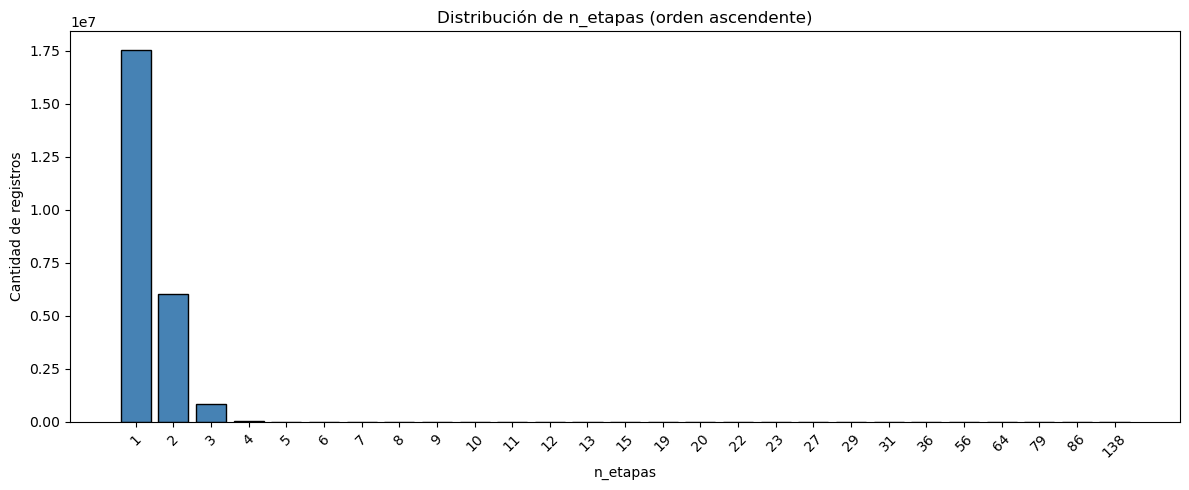

In [13]:
con = duckdb.connect()

# Distribución de n_etapas (archivo trips_2024)
ruta_2024 = str(PROC / "Trips" / "2024" / "trips_2024_raw.parquet").replace("\\", "/")

q = f"""
SELECT n_etapas, COUNT(*) AS cnt
FROM read_parquet('{ruta_2024}')
GROUP BY n_etapas
ORDER BY n_etapas
"""
dist = con.sql(q).df()

# Graficar distribución de n_etapas ordenada ascendentemente (numérico)
dist_sorted = dist.copy()
dist_sorted['n_etapas_num'] = pd.to_numeric(dist_sorted['n_etapas'], errors='coerce')
dist_sorted = dist_sorted.sort_values('n_etapas_num').reset_index(drop=True)

# etiquetas legibles (preservar 'NA' si corresponde)
x_labels = dist_sorted['n_etapas_num'].apply(lambda x: 'NA' if pd.isna(x) else str(int(x)))

plt.figure(figsize=(12, 5))
plt.bar(x_labels, dist_sorted['cnt'], color='steelblue', edgecolor='black')
plt.xlabel('n_etapas')
plt.ylabel('Cantidad de registros')
plt.title('Distribución de n_etapas (orden ascendente)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

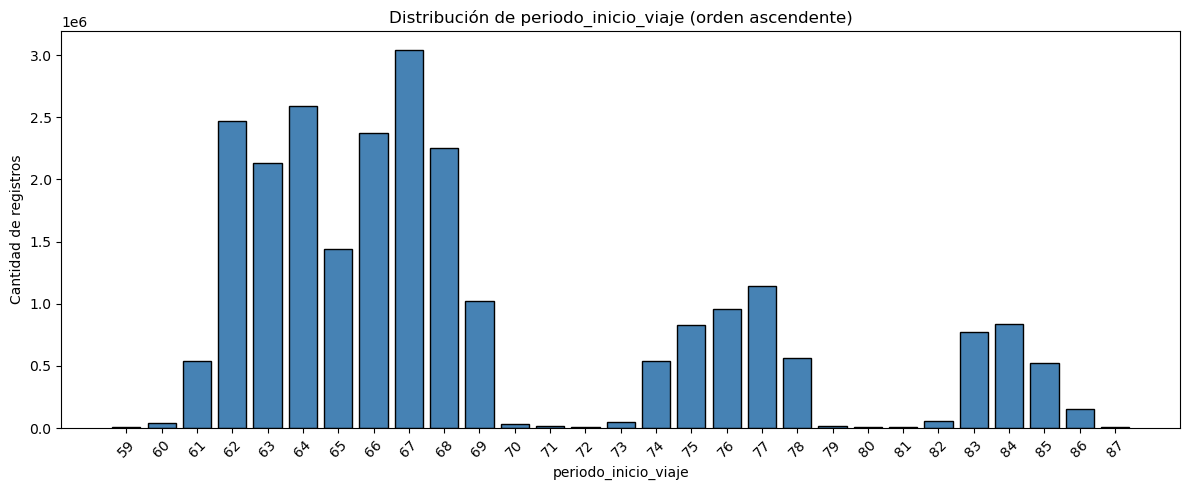

In [11]:
# Distribución de periodo_inicio_viaje (archivo trips_2024)
q_periodo = f"""
SELECT periodo_inicio_viaje, COUNT(*) AS cnt
FROM read_parquet('{ruta_2024}')
WHERE periodo_inicio_viaje IS NOT NULL
GROUP BY periodo_inicio_viaje
ORDER BY periodo_inicio_viaje
"""
dist_periodo = con.sql(q_periodo).df()

# Convertir a numérico para ordenar correctamente
dist_periodo['periodo_num'] = pd.to_numeric(dist_periodo['periodo_inicio_viaje'], errors='coerce')
dist_periodo = dist_periodo.sort_values('periodo_num').reset_index(drop=True)

# Etiquetas legibles
x_labels_periodo = dist_periodo['periodo_inicio_viaje'].astype(str)

plt.figure(figsize=(12, 5))
plt.bar(x_labels_periodo, dist_periodo['cnt'], color='steelblue', edgecolor='black')
plt.xlabel('periodo_inicio_viaje')
plt.ylabel('Cantidad de registros')
plt.title('Distribución de periodo_inicio_viaje (orden ascendente)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

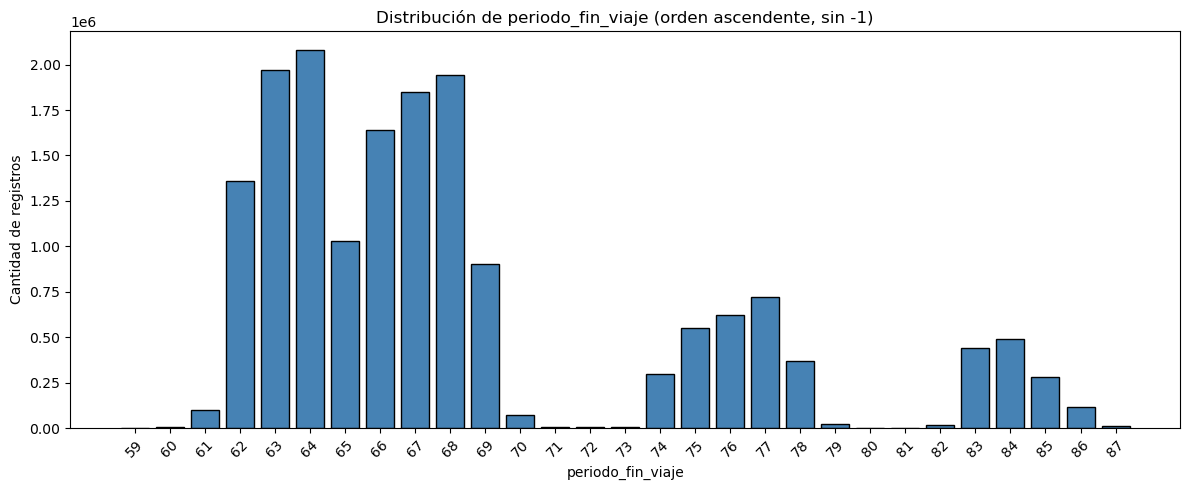

In [12]:
# Distribución de periodo_fin_viaje (orden ascendente, excluyendo -1)
q_periodo_fin = f"""
SELECT periodo_fin_viaje, COUNT(*) AS cnt
FROM read_parquet('{ruta_2024}')
WHERE periodo_fin_viaje IS NOT NULL
    AND periodo_fin_viaje <> -1
GROUP BY periodo_fin_viaje
ORDER BY periodo_fin_viaje
"""

dist_periodo_fin = con.sql(q_periodo_fin).df()
dist_periodo_fin['periodo_num'] = pd.to_numeric(dist_periodo_fin['periodo_fin_viaje'], errors='coerce')
dist_periodo_fin = dist_periodo_fin.sort_values('periodo_num').reset_index(drop=True)

plt.figure(figsize=(12, 5))
plt.bar(dist_periodo_fin['periodo_fin_viaje'].astype(str), dist_periodo_fin['cnt'],
                color='steelblue', edgecolor='black')
plt.xlabel('periodo_fin_viaje')
plt.ylabel('Cantidad de registros')
plt.title('Distribución de periodo_fin_viaje (orden ascendente, sin -1)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

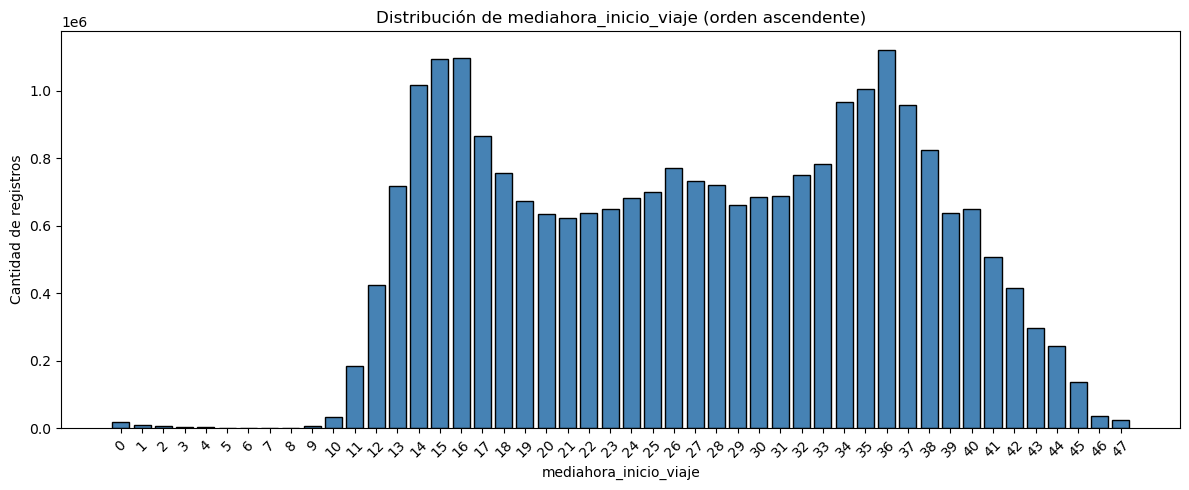

In [14]:
# Distribución de mediahora_inicio_viaje (orden ascendente)
q_mediahora = f"""
SELECT mediahora_inicio_viaje, COUNT(*) AS cnt
FROM read_parquet('{ruta_2024}')
WHERE mediahora_inicio_viaje IS NOT NULL
GROUP BY mediahora_inicio_viaje
ORDER BY mediahora_inicio_viaje
"""
dist_mediahora = con.sql(q_mediahora).df()

# Convertir a numérico para ordenar correctamente
dist_mediahora['mediahora_num'] = pd.to_numeric(dist_mediahora['mediahora_inicio_viaje'], errors='coerce')
dist_mediahora = dist_mediahora.sort_values('mediahora_num').reset_index(drop=True)

# Etiquetas legibles
x_labels_mediahora = dist_mediahora['mediahora_inicio_viaje'].astype(str)

plt.figure(figsize=(12, 5))
plt.bar(x_labels_mediahora, dist_mediahora['cnt'], color='steelblue', edgecolor='black')
plt.xlabel('mediahora_inicio_viaje')
plt.ylabel('Cantidad de registros')
plt.title('Distribución de mediahora_inicio_viaje (orden ascendente)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

con.close()

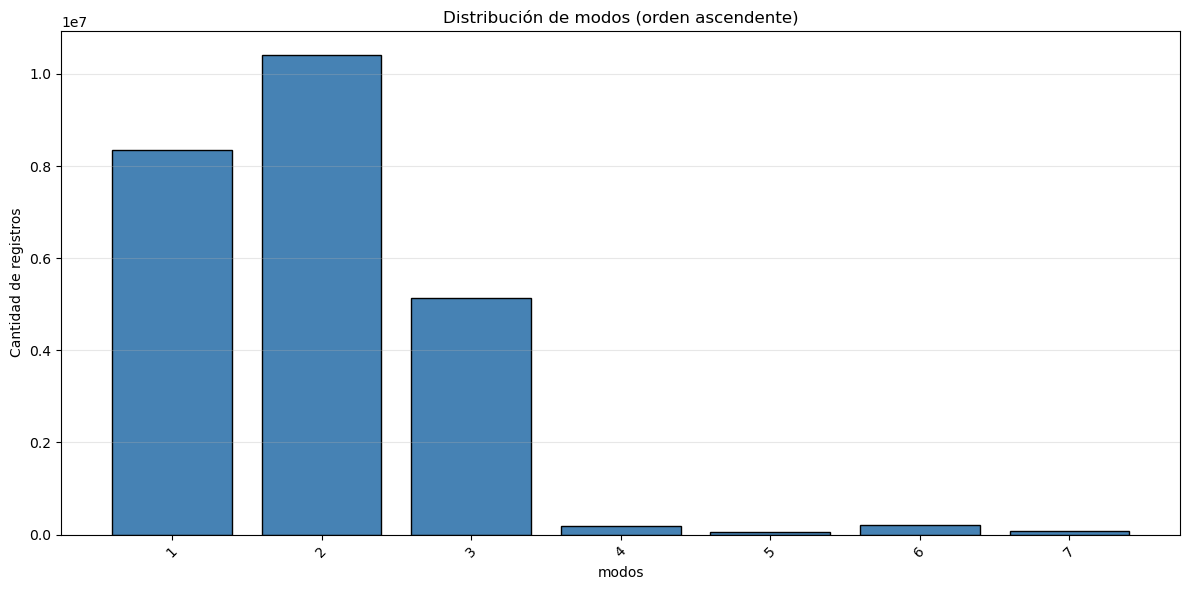

In [15]:
# Obtener distribución de 'modos' desde el parquet y graficar en orden ascendente
con = duckdb.connect()

q_modos = f"""
SELECT modos, COUNT(*) AS cnt
FROM read_parquet('{ruta_2024}')
GROUP BY modos
ORDER BY modos
"""
modos_df = con.sql(q_modos).df()
con.close()

# Normalizar/limpiar etiqueta de modo nulo y ordenar ascendentemente
modos_df['modos'] = modos_df['modos'].fillna('NA').astype(str)
modos_df = modos_df.sort_values('modos').reset_index(drop=True)

plt.figure(figsize=(12,6))
plt.bar(modos_df['modos'], modos_df['cnt'], color='steelblue', edgecolor='black')
plt.title('Distribución de modos (orden ascendente)')
plt.xlabel('modos')
plt.ylabel('Cantidad de registros')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

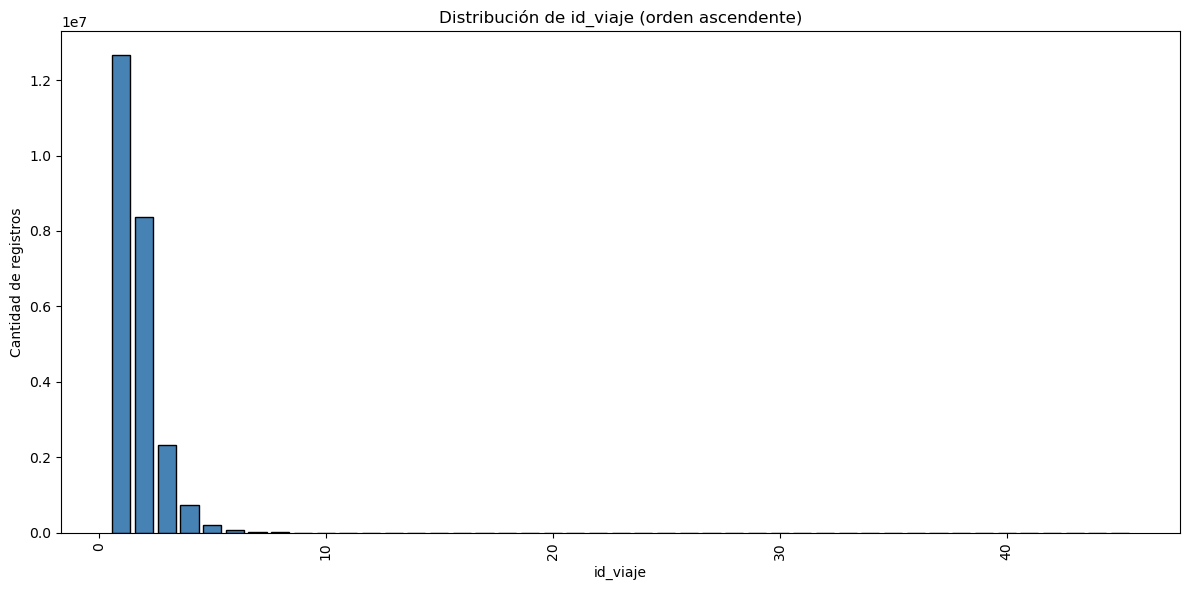

In [17]:
# Distribución de id_viaje ordenada ascendentemente
con = duckdb.connect()
q = f"SELECT id_viaje, COUNT(*) AS cnt FROM read_parquet('{ruta_2024}') GROUP BY id_viaje ORDER BY id_viaje ASC"
id_dist = con.sql(q).df()
con.close()

if id_dist.empty:
    print("No hay id_viaje para graficar")
else:
    if len(id_dist) > 2000:
        plt.figure(figsize=(10, 5))
        plt.hist(id_dist['cnt'], bins=50, edgecolor='black', log=True)
        plt.title('Histograma de frecuencia de id_viaje (demasiados ids para barra)')
        plt.xlabel('Veces que aparece id_viaje')
        plt.ylabel('Cantidad de ids (escala log)')
        plt.grid(alpha=0.3)
        plt.show()
    else:
        plt.figure(figsize=(12, 6))
        plt.bar(id_dist['id_viaje'].astype(int), id_dist['cnt'], color='steelblue', edgecolor='black')
        plt.title('Distribución de id_viaje (orden ascendente)')
        plt.xlabel('id_viaje')
        plt.ylabel('Cantidad de registros')
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()

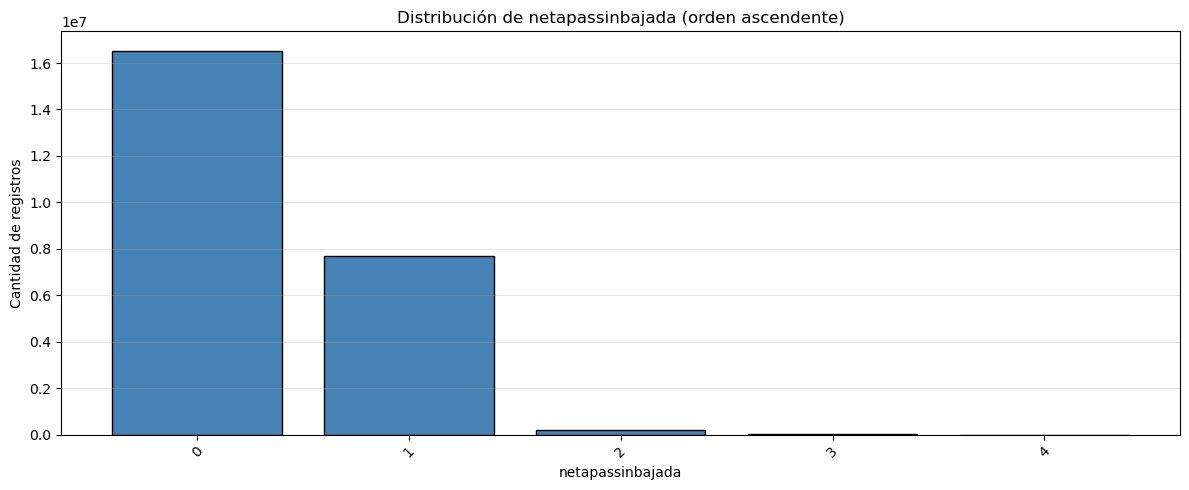

In [18]:
# Distribución de netapassinbajada en orden ascendente
con = duckdb.connect()
q = f"""
SELECT netapassinbajada, COUNT(*) AS cnt
FROM read_parquet('{ruta_2024}')
GROUP BY netapassinbajada
"""
dist_netapa = con.sql(q).df()
con.close()

dist_netapa['netapa_num'] = pd.to_numeric(dist_netapa['netapassinbajada'], errors='coerce')
dist_netapa = dist_netapa.sort_values('netapa_num').reset_index(drop=True)

# Excluir nulos para la gráfica
dist_netapa_clean = dist_netapa[dist_netapa['netapa_num'].notna()]

plt.figure(figsize=(12, 5))
plt.bar(dist_netapa_clean['netapassinbajada'].astype(str), dist_netapa_clean['cnt'],
    color='steelblue', edgecolor='black')
plt.xlabel('netapassinbajada')
plt.ylabel('Cantidad de registros')
plt.title('Distribución de netapassinbajada (orden ascendente)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

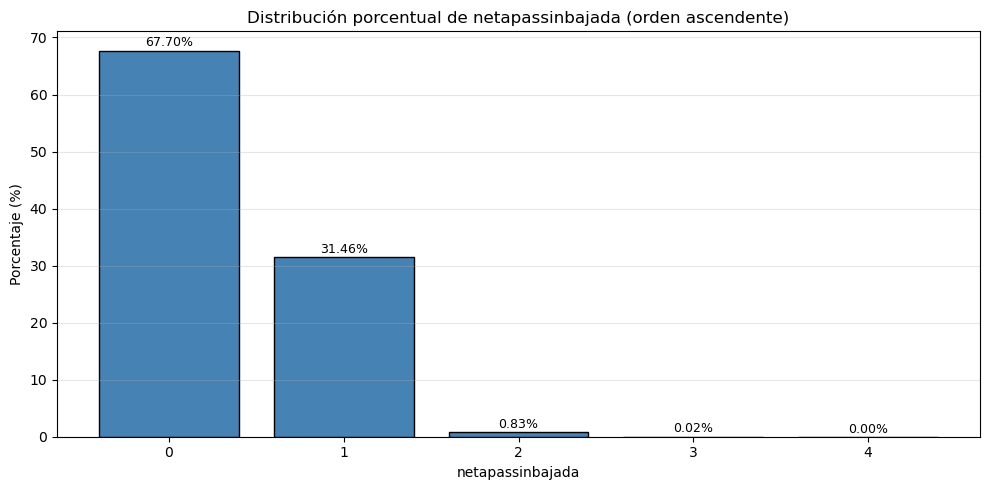

In [19]:
# Graficar distribución porcentual de netapassinbajada en orden ascendente
total = dist_netapa_clean['cnt'].sum()
df_pct = dist_netapa_clean.copy()
df_pct['pct'] = df_pct['cnt'] / total * 100
df_pct = df_pct.sort_values('netapa_num').reset_index(drop=True)

plt.figure(figsize=(10, 5))
x = df_pct['netapassinbajada'].astype(str)
y = df_pct['pct']
bars = plt.bar(x, y, color='steelblue', edgecolor='black')
plt.xlabel('netapassinbajada')
plt.ylabel('Porcentaje (%)')
plt.title('Distribución porcentual de netapassinbajada (orden ascendente)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

for b, val in zip(bars, y):
    plt.text(b.get_x() + b.get_width() / 2, val + 0.2, f'{val:.2f}%', ha='center', va='bottom', fontsize=9)

plt.show()

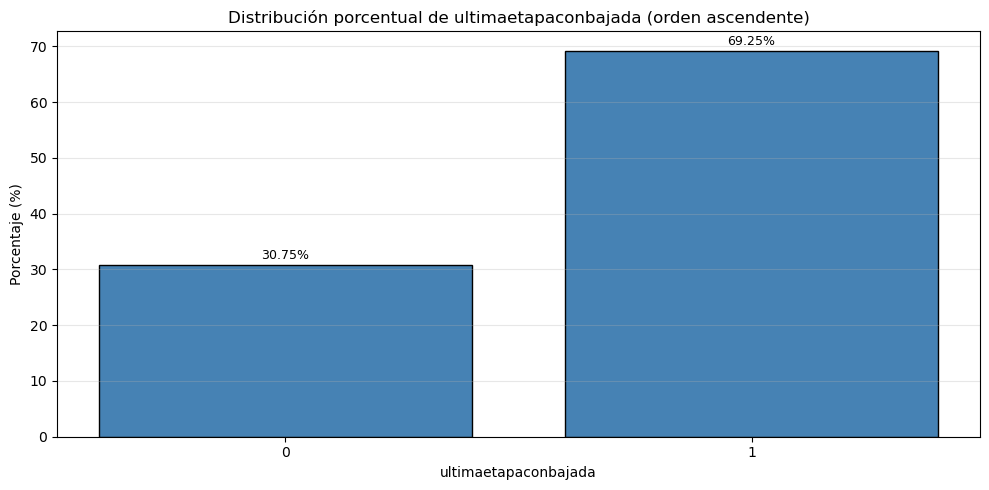

Distribución de ultimaetapaconbajada (%):
ultimaetapaconbajada      cnt       pct
                   0  7512594 30.750983
                   1 16917825 69.249017


In [20]:
con = duckdb.connect()

q_ultimaetapa = f"""
SELECT ultimaetapaconbajada, COUNT(*) AS cnt
FROM read_parquet('{ruta_2024}')
WHERE ultimaetapaconbajada IS NOT NULL
GROUP BY ultimaetapaconbajada
ORDER BY ultimaetapaconbajada
"""
dist_ultimaetapa = con.sql(q_ultimaetapa).df()
con.close()

# Convertir a numérico para ordenar correctamente
dist_ultimaetapa['ultimaetapa_num'] = pd.to_numeric(dist_ultimaetapa['ultimaetapaconbajada'], errors='coerce')
dist_ultimaetapa = dist_ultimaetapa.sort_values('ultimaetapa_num').reset_index(drop=True)

# Calcular porcentajes
total = dist_ultimaetapa['cnt'].sum()
dist_ultimaetapa['pct'] = dist_ultimaetapa['cnt'] / total * 100

# Graficar
plt.figure(figsize=(10, 5))
x = dist_ultimaetapa['ultimaetapaconbajada'].astype(str)
y = dist_ultimaetapa['pct']
bars = plt.bar(x, y, color='steelblue', edgecolor='black')
plt.xlabel('ultimaetapaconbajada')
plt.ylabel('Porcentaje (%)')
plt.title('Distribución porcentual de ultimaetapaconbajada (orden ascendente)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

for b, val in zip(bars, y):
    plt.text(b.get_x() + b.get_width() / 2, val + 0.5, f'{val:.2f}%', ha='center', va='bottom', fontsize=9)

plt.show()

# Mostrar tabla
print("Distribución de ultimaetapaconbajada (%):")
print(dist_ultimaetapa[['ultimaetapaconbajada', 'cnt', 'pct']].to_string(index=False))

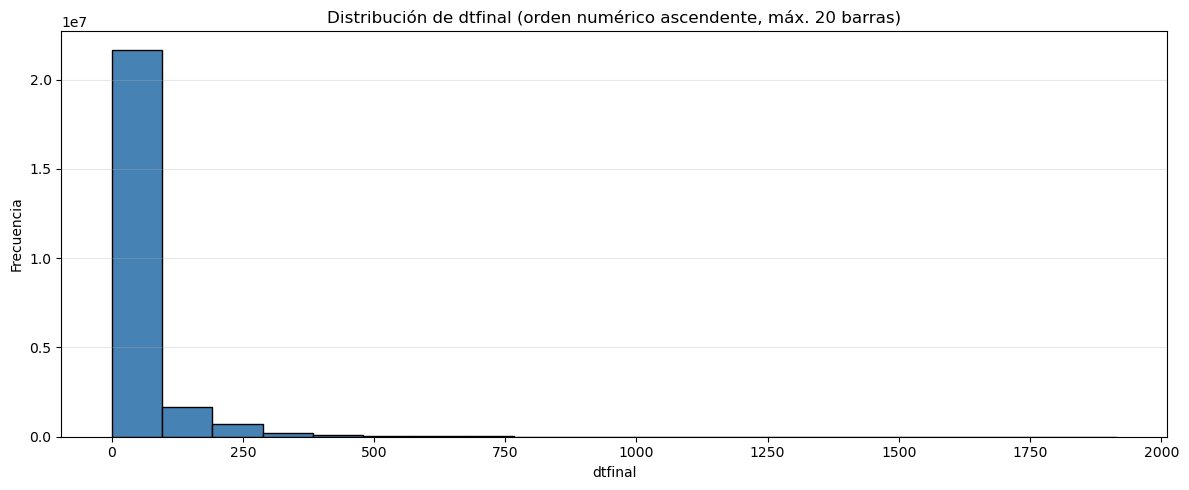

In [8]:
con = duckdb.connect()

ruta_2024 = str(PROC / "Trips" / "2024" / "trips_2024_raw.parquet").replace("\\", "/")

df_dtfinal = con.sql(f"""
    SELECT dtfinal
    FROM read_parquet('{ruta_2024}')
    WHERE dtfinal IS NOT NULL
""").df()

con.close()

dtfinal_num = pd.to_numeric(df_dtfinal["dtfinal"], errors="coerce").dropna()

if dtfinal_num.empty:
    print("No hay valores numéricos válidos en dtfinal para graficar.")
else:
    bins = min(20, max(1, dtfinal_num.nunique()))
    counts, edges = np.histogram(dtfinal_num, bins=bins)

    plt.figure(figsize=(12, 5))
    plt.bar(
        edges[:-1],
        counts,
        width=np.diff(edges),
        align="edge",
        edgecolor="black",
        color="steelblue"
    )
    plt.title("Distribución de dtfinal (orden numérico ascendente, máx. 20 barras)")
    plt.xlabel("dtfinal")
    plt.ylabel("Frecuencia")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

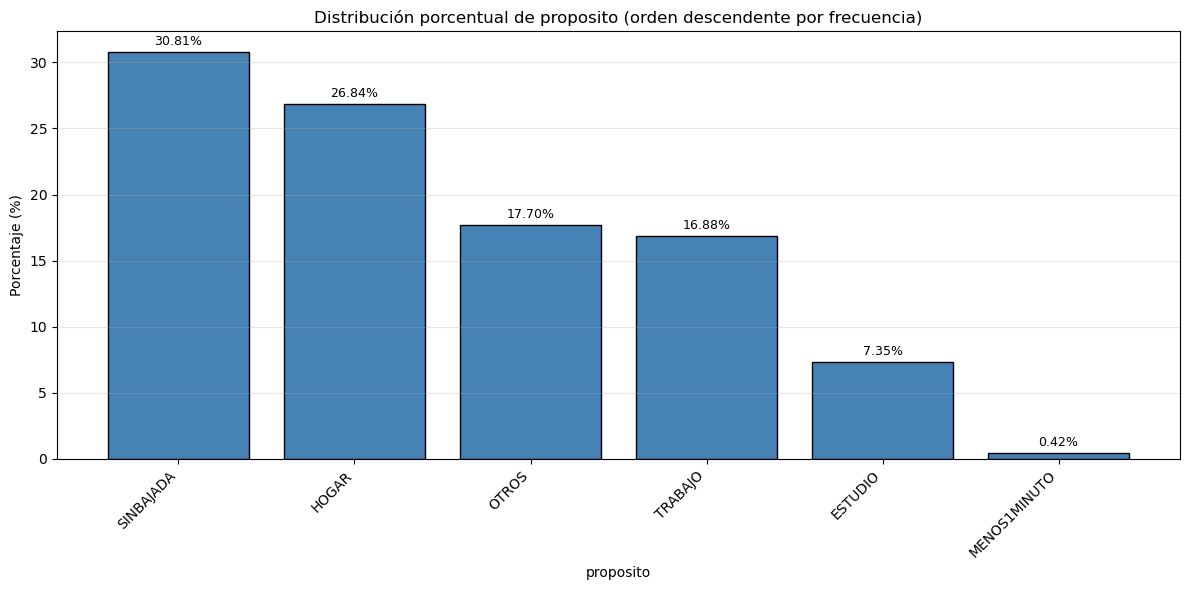

Distribución de proposito (%):
   proposito     cnt       pct
   SINBAJADA 7526796 30.809115
       HOGAR 6557468 26.841406
       OTROS 4323690 17.697977
     TRABAJO 4124375 16.882130
     ESTUDIO 1794845  7.346763
MENOS1MINUTO  103245  0.422608


In [9]:
con = duckdb.connect()

q_proposito = f"""
SELECT proposito, COUNT(*) AS cnt
FROM read_parquet('{ruta_2024}')
WHERE proposito IS NOT NULL
GROUP BY proposito
ORDER BY cnt DESC
"""
dist_proposito = con.sql(q_proposito).df()
con.close()

# Calcular porcentajes
total = dist_proposito['cnt'].sum()
dist_proposito['pct'] = dist_proposito['cnt'] / total * 100

# Graficar
plt.figure(figsize=(12, 6))
x = dist_proposito['proposito'].astype(str)
y = dist_proposito['pct']
bars = plt.bar(x, y, color='steelblue', edgecolor='black')
plt.xlabel('proposito')
plt.ylabel('Porcentaje (%)')
plt.title('Distribución porcentual de proposito (orden descendente por frecuencia)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

for b, val in zip(bars, y):
    plt.text(b.get_x() + b.get_width() / 2, val + 0.3, f'{val:.2f}%', ha='center', va='bottom', fontsize=9)

plt.show()

# Mostrar tabla
print("Distribución de proposito (%):")
print(dist_proposito[['proposito', 'cnt', 'pct']].to_string(index=False))

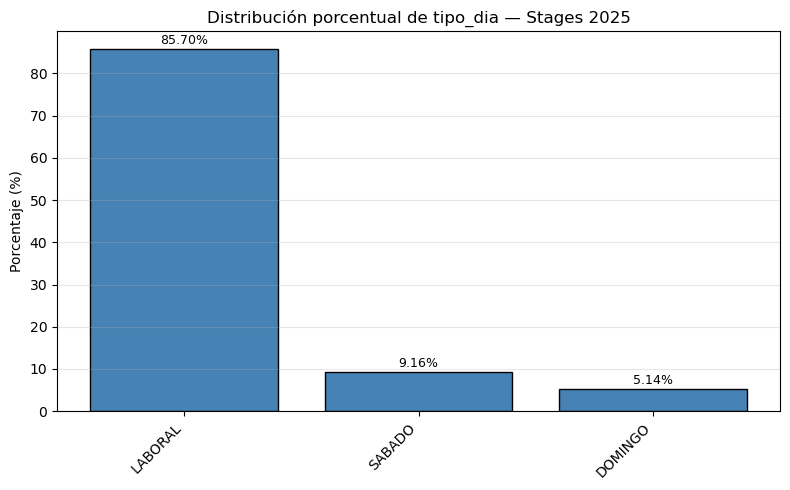

In [15]:
# Distribución porcentual de 'tipodia' — Stages 2025
con = duckdb.connect()

q = f"""
SELECT tipo_dia, COUNT(*) AS cnt
FROM read_parquet('{ruta}')
WHERE tipo_dia IS NOT NULL
GROUP BY tipo_dia
ORDER BY cnt DESC
"""
df_tipodia = con.sql(q).df()
total = df_tipodia['cnt'].sum()
df_tipodia['pct'] = df_tipodia['cnt'] / total * 100

plt.figure(figsize=(8, 5))
x = df_tipodia['tipo_dia'].astype(str)
y = df_tipodia['pct']
bars = plt.bar(x, y, color='steelblue', edgecolor='black')
plt.ylabel('Porcentaje (%)')
plt.title('Distribución porcentual de tipo_dia — Stages 2025')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

for b, val in zip(bars, y):
    plt.text(b.get_x() + b.get_width() / 2, val + 0.5, f'{val:.2f}%', ha='center', va='bottom', fontsize=9)

plt.show()